# Supplementary Figures S2–S3: AGIST

Compare the simulated populations with their known trajectories, growth and interaction programs. Recalculate the summaries for S2–S3 and draw both figures.


## Before you start

Follow the [source installation](../../installation.md), then run these cells in order. The numerical inputs are included with the code. The notebook saves new figures and their calculation tables.

To generate these inputs from fitted models, see the [calculation guide](../../reference/figure_sources/agist.md).


## Load the figure data included with the package

In [1]:
import os
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results import calculate_agist_figure_panels, load_agist_figures, write_agist_figure_tables

output_dir = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")) / "outputs" / "agist_figures"
output_dir.mkdir(parents=True, exist_ok=True)
data = load_agist_figures()

## Recalculate the panel tables

In [2]:
panels = calculate_agist_figure_panels(data)
tables = write_agist_figure_tables(panels, output_dir)
{name: path.name for name, path in tables.items()}

{'s2_by_time': 's2_velocity_by_time.csv',
 's2_by_cluster': 's2_velocity_by_state_cluster.csv',
 's2_overall': 's2_velocity_overall.csv',
 's2_time_cluster': 's2_velocity_by_time_and_state_cluster.csv',
 's3_growth': 's3_growth_summary.csv',
 's3_potential': 's3_potential_curve.csv',
 's3_ablation': 's3_ablation_summary.csv'}

## Rebuild the PDF and PNG files

In [3]:
from reproduction.paper_figures import draw_supplementary
figures = draw_supplementary([2, 3], output_dir)
{
    figure: {"pdf": paths[0].name, "png": paths[1].name}
    for figure, paths in figures.items()
}

{'s2': {'pdf': 'S2.pdf', 'png': 'S2.png'},
 's3': {'pdf': 'S3.pdf', 'png': 'S3.png'}}

## Preview the reproduced figures

S2


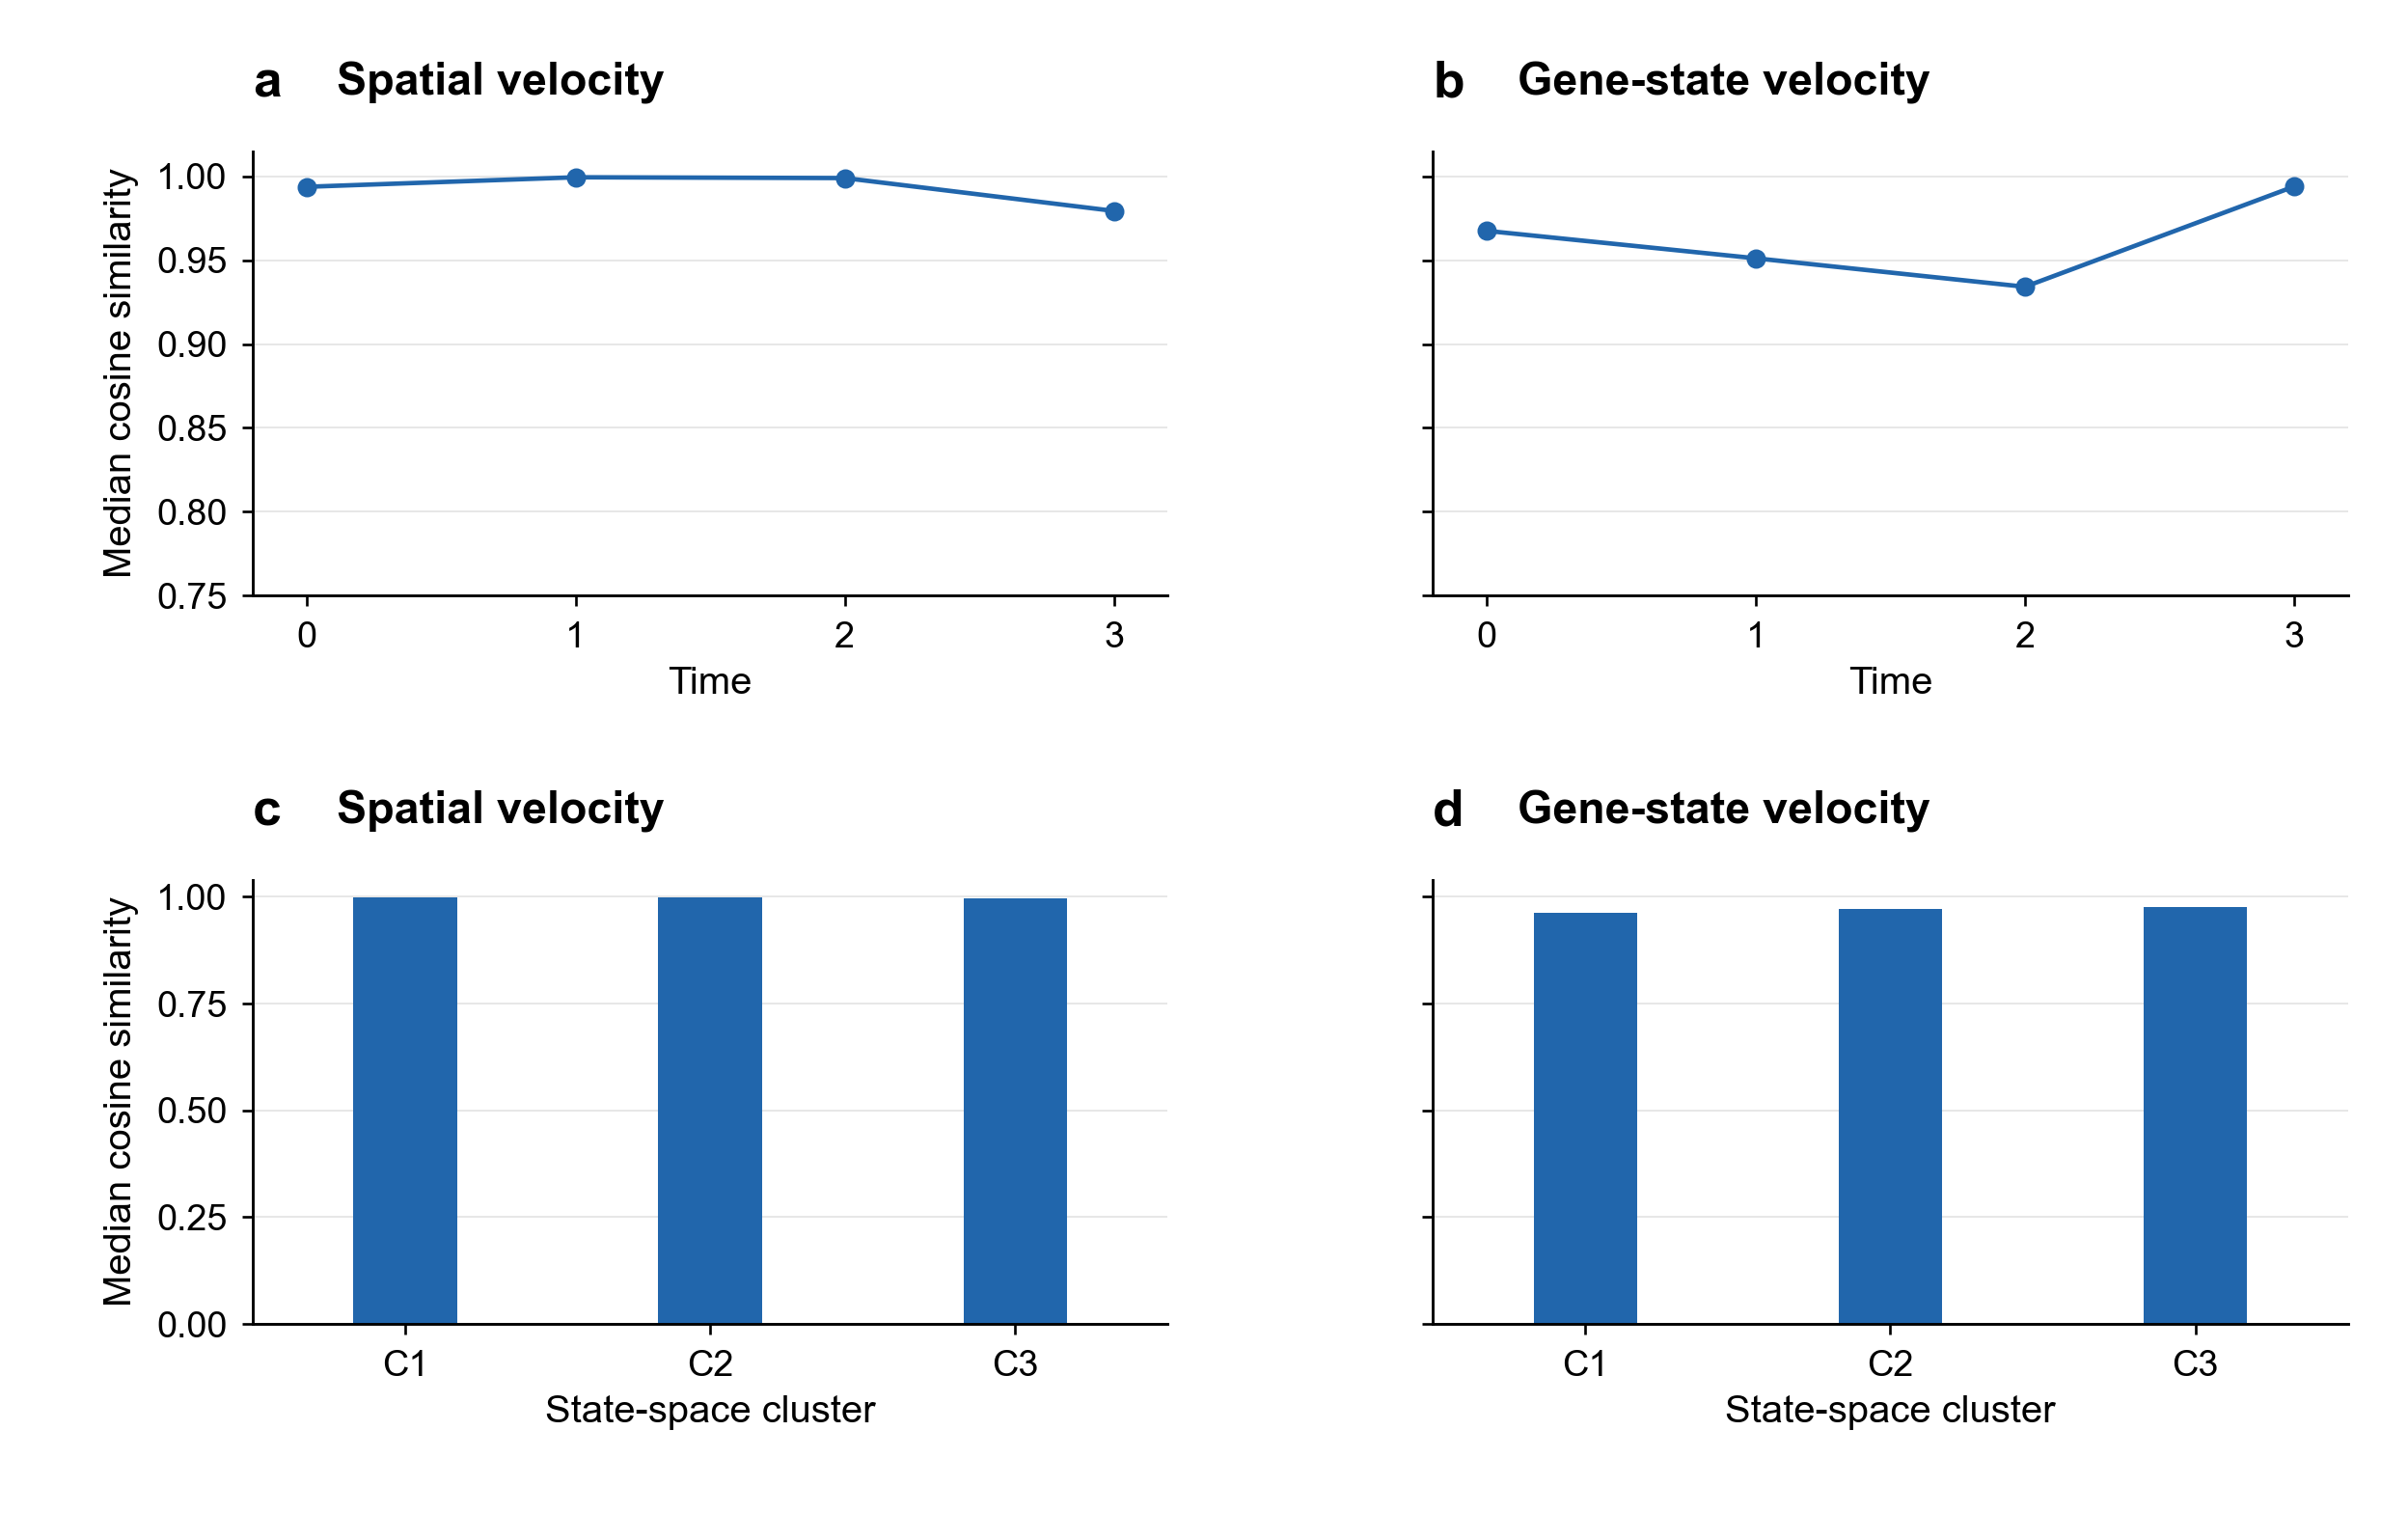

S3


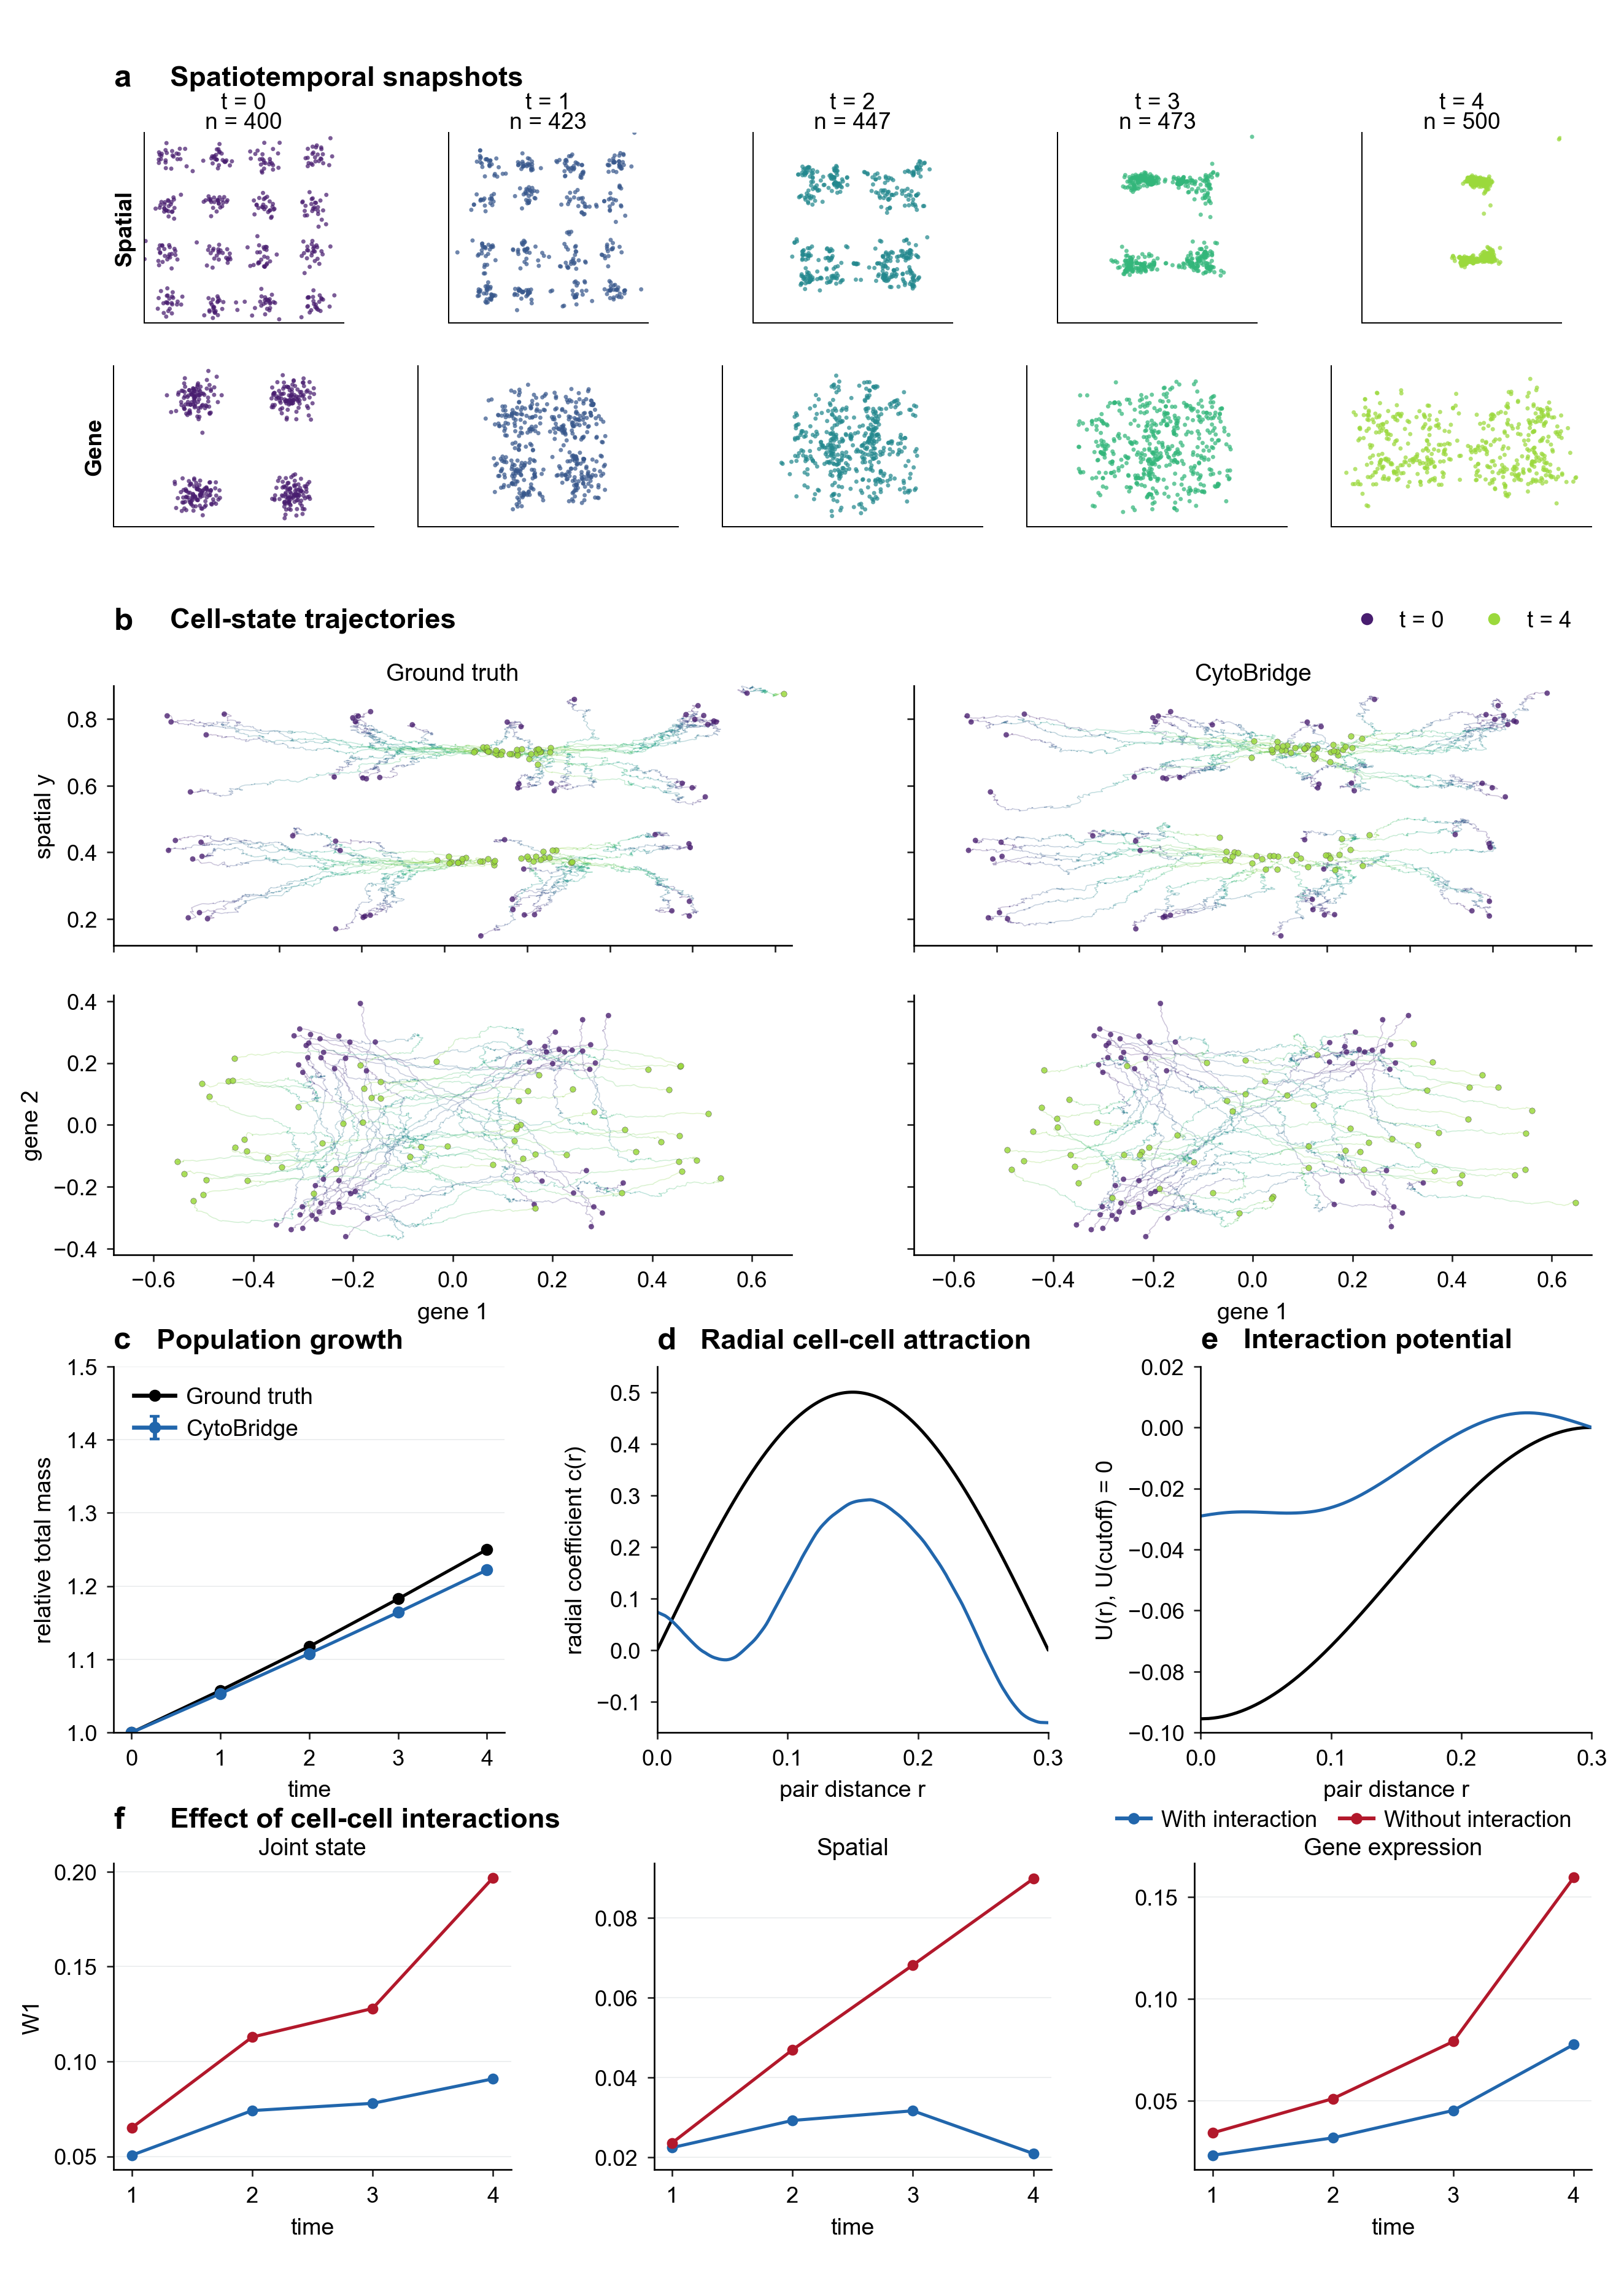

In [4]:
for figure, (_, png_path) in figures.items():
    print(figure.upper())
    display(Image(filename=str(png_path), width=720))